# Food 101

The goal is to beat **[DeepFood](https://www.researchgate.net/publication/304163308_DeepFood_Deep_Learning-Based_Food_Image_Recognition_for_Computer-Aided_Dietary_Assessment)**, a 2016 paper which used a Convolutional Neural Network trained for 2-3 days to achieve 77.4% top-1 accuracy.


### Imports

In [123]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import mixed_precision

### Helper Functions

In [121]:
from helper_functions import create_tensorboard_callback

### Check GPU

This block identifies the hardware and prepares the memory for training.

In [102]:
# Check for GPU 
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    try:
        # 'Memory Growth' is highly recommended for local machines (Windows/Mac).
        # It prevents TensorFlow from hogging all of RAM at once, 
        # allowing your system to stay responsive for other apps.
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"GPUs Detected: {len(gpus)}")
        print(f"Device Details: {gpus}")
    except RuntimeError as e:
        print(e)
else:
    print("""
    No GPU detected. 
    - Mac: ensure 'tensorflow-metal' is installed.
    - Windows/Colab: ensure CUDA drivers are active.""")


GPUs Detected: 1
Device Details: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


2. Mixed Precision Explanation (For your Notebook)
You can paste this Markdown text into your notebook to explain the "Why" and "How" to your GitHub users:

What is Mixed Precision?
Mixed precision uses a combination of 16-bit and 32-bit floating-point types during training. This makes models run faster and use less memory.

Hardware Requirements
NVIDIA (Windows/Colab): You need a Compute Capability score of 7.0 or higher. This includes the T4 in Colab and any RTX series card. These GPUs have "Tensor Cores" that accelerate 16-bit math. Older cards (GTX 10-series) lack these cores and may actually run slower with mixed precision.

Apple Silicon (Mac): All M-series chips (M1 through M4) support mixed precision natively via the Metal API.

### Exploring Dataset


Most popular datasets in the machine learning world, can be accessed through [TensorFlow Datasets (TFDS)](https://www.tensorflow.org/datasets/overview).  

In [103]:
# Get Tensorflow Datasets
import tensorflow_datasets as tfds

In [104]:
# List all available datasets
datasets_list = tfds.list_builders() #get all available datasets in TFDS
print("food101" in datasets_list)

True


[Tensorflow Datasets Food101](https://www.tensorflow.org/datasets/catalog/food101)

In [105]:
# Load in the data 
(train_data, test_data), ds_info = tfds.load(name="food101",
                                             split=["train", "validation"],
                                             shuffle_files=True,
                                             as_supervised=True,
                                             with_info=True)

In [106]:
# Meta data about the dataset
ds_info

tfds.core.DatasetInfo(
    name='food101',
    full_name='food101/2.0.0',
    description="""
    This dataset consists of 101 food categories, with 101'000 images. For each class, 250 manually reviewed test images are provided as well as 750 training images. On purpose, the training images were not cleaned, and thus still contain some amount of noise. This comes mostly in the form of intense colors and sometimes wrong labels. All images were rescaled to have a maximum side length of 512 pixels.
    """,
    homepage='https://data.vision.ee.ethz.ch/cvl/datasets_extra/food-101/',
    data_dir='/Users/puneet/tensorflow_datasets/food101/2.0.0',
    file_format=tfrecord,
    download_size=4.65 GiB,
    dataset_size=4.77 GiB,
    features=FeaturesDict({
        'image': Image(shape=(None, None, 3), dtype=uint8),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=101),
    }),
    supervised_keys=('image', 'label'),
    disable_shuffling=False,
    nondeterministic_order=False,
 

In [107]:
# Features of Food101
ds_info.features

FeaturesDict({
    'image': Image(shape=(None, None, 3), dtype=uint8),
    'label': ClassLabel(shape=(), dtype=int64, num_classes=101),
})

In [108]:
# Get class names
class_names = ds_info.features["label"].names
class_names[:10]

['apple_pie',
 'baby_back_ribs',
 'baklava',
 'beef_carpaccio',
 'beef_tartare',
 'beet_salad',
 'beignets',
 'bibimbap',
 'bread_pudding',
 'breakfast_burrito']

In [109]:
# Take one sample 
train_one_sample = train_data.take(1) # samples are in format (image, label)
train_one_sample

<_TakeDataset element_spec=(TensorSpec(shape=(None, None, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>

Loop through single training sample and get some info from the `image` and `label`.

In [110]:
# Output info about our training sample
for image, label in train_one_sample:
  print(f"""
  Image shape: {image.shape}
  Image dtype: {image.dtype}
  Target class from Food101 (tensor form): {label}
  Class name (str form): {class_names[label]}
        """)


  Image shape: (384, 512, 3)
  Image dtype: <dtype: 'uint8'>
  Target class from Food101 (tensor form): 97
  Class name (str form): takoyaki
        


2026-03-21 17:13:32.624637: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


The code block below will give a different result each time. Because the paramter `shuffle_files` is set as `True` in `tfds.load()`

The images have different shapes, for example `(512, 342, 3)` and `(512, 512, 3)` 
(height, width, color_channels).

The image from Food101 Datasets

In [111]:
image

<tf.Tensor: shape=(384, 512, 3), dtype=uint8, numpy=
array([[[ 54,  30,  26],
        [ 57,  33,  29],
        [ 72,  49,  43],
        ...,
        [192, 184, 163],
        [190, 179, 159],
        [181, 169, 147]],

       [[ 51,  28,  22],
        [ 60,  37,  31],
        [ 81,  58,  52],
        ...,
        [191, 183, 162],
        [189, 176, 157],
        [176, 164, 142]],

       [[ 78,  58,  49],
        [ 96,  76,  67],
        [122, 102,  93],
        ...,
        [191, 183, 162],
        [188, 175, 156],
        [172, 157, 136]],

       ...,

       [[162, 140, 117],
        [164, 142, 119],
        [169, 147, 126],
        ...,
        [  5,   5,   5],
        [  6,   6,   6],
        [  6,   6,   6]],

       [[168, 146, 123],
        [170, 148, 125],
        [176, 154, 131],
        ...,
        [  5,   5,   5],
        [  6,   6,   6],
        [  6,   6,   6]],

       [[173, 151, 128],
        [176, 154, 131],
        [182, 160, 137],
        ...,
        [  4,   4,   

In [112]:
# What are the min and max values?
tf.reduce_min(image), tf.reduce_max(image)

(<tf.Tensor: shape=(), dtype=uint8, numpy=0>,
 <tf.Tensor: shape=(), dtype=uint8, numpy=255>)

#### Let plot the image

2026-03-21 17:13:32.683840: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


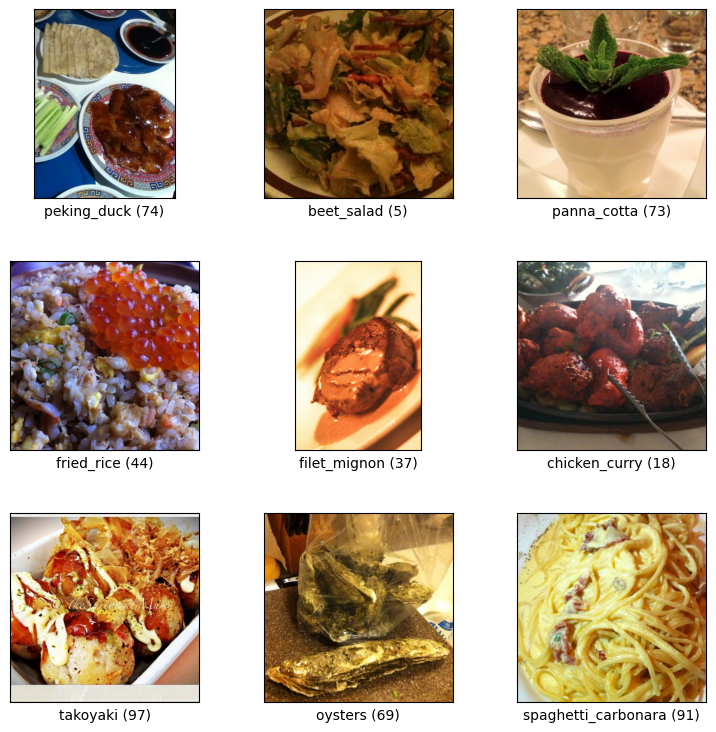

In [113]:
fig = tfds.show_examples(train_data, ds_info)

(-0.5, 511.5, 383.5, -0.5)

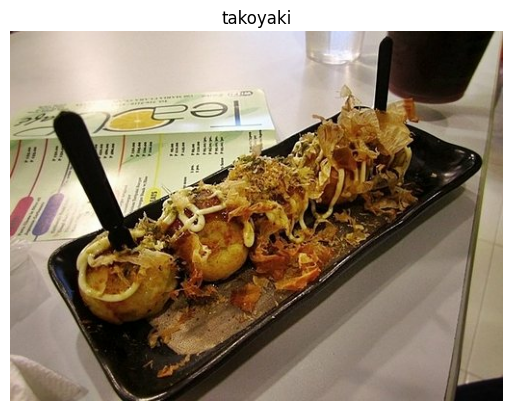

In [114]:
# Plot an single image tensor
plt.imshow(image)
plt.title(class_names[label]) # add title to image by indexing on class_names list
plt.axis(False)

### Prepocessing of Data

Data is currently:
* In `uint8` data type
* Comprised of all differnet sized tensors (different sized images)
* Not scaled (the pixel values are between 0 & 255)

After Preprocessing Data
* In `float32` data type
* Have all of the same size tensors (batches require all tensors have the same shape, e.g. `(224, 224, 3)`)
* Scaled (values between 0 & 1), also called normalized

In [115]:
# Make a function for preprocessing images
def preprocess_img(image, label, img_shape=224):
    """
    Converts image datatype from 'uint8' -> 'float32' and reshapes image to
    [img_shape, img_shape, color_channels]
    """
    image = tf.image.resize(image, [img_shape, img_shape]) # reshape to img_shape
    return tf.cast(image, tf.float32), label # return (float32_image, label) tuple

`preprocess_img()` function above takes image and label as input (even though it does nothing to the label) because our dataset is currently in the tuple structure `(image, label)`.

Try function out on a target image.

In [116]:
# Preprocess a single sample image and check the outputs
preprocessed_img = preprocess_img(image, label)[0]
print(f"Image before preprocessing:\n {image[:2]}...,\nShape: {image.shape},\nDatatype: {image.dtype}\n")
print(f"Image after preprocessing:\n {preprocessed_img[:2]}...,\nShape: {preprocessed_img.shape},\nDatatype: {preprocessed_img.dtype}")

Image before preprocessing:
 [[[ 54  30  26]
  [ 57  33  29]
  [ 72  49  43]
  ...
  [192 184 163]
  [190 179 159]
  [181 169 147]]

 [[ 51  28  22]
  [ 60  37  31]
  [ 81  58  52]
  ...
  [191 183 162]
  [189 176 157]
  [176 164 142]]]...,
Shape: (384, 512, 3),
Datatype: <dtype: 'uint8'>

Image after preprocessing:
 [[[ 56.23469   32.591835  27.877552]
  [ 98.16328   75.16328   68.50001 ]
  [121.62245  101.62245   91.63265 ]
  ...
  [191.72456  191.36736  170.93883 ]
  [202.18863  196.9743   176.90286 ]
  [185.918    174.10167  153.6169  ]]

 [[ 93.47959   73.55102   64.19388 ]
  [144.57143  124.64286  113.561226]
  [169.66327  150.20409  138.79082 ]
  ...
  [196.22955  195.22955  176.80103 ]
  [202.02025  194.9335   175.87225 ]
  [182.24942  168.44324  148.72888 ]]]...,
Shape: (224, 224, 3),
Datatype: <dtype: 'float32'>


The input image gets converted from `uint8` to `float32` and gets reshaped from its current shape to `(224, 224, 3)`.

Plot the preprocessed image to see

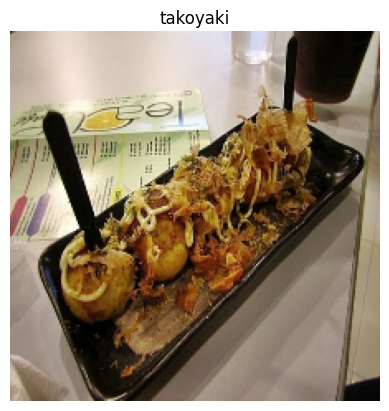

In [117]:
# We can still plot our preprocessed image as long as we 
plt.imshow(preprocessed_img/255.) # divide by 255 (for matplotlib capatibility)
plt.title(class_names[label])
plt.axis(False);

### Prepare Dataset

In [118]:
# Map preprocessing function to training data (and paralellize)
train_data = train_data.map(map_func=preprocess_img, num_parallel_calls=tf.data.AUTOTUNE)
# Shuffle train_data and turn it into batches and prefetch it (load it faster)
train_data = train_data.shuffle(buffer_size=1000).batch(batch_size=32).prefetch(buffer_size=tf.data.AUTOTUNE)

# Map prepreprocessing function to test data
test_data = test_data.map(preprocess_img, num_parallel_calls=tf.data.AUTOTUNE)
# Turn test data into batches (don't need to shuffle)
test_data = test_data.batch(32).prefetch(tf.data.AUTOTUNE)

In [120]:
train_data, test_data

(<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>,
 <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>)

### Create modelling callbacks

In [122]:
# Create ModelCheckpoint callback to save model's progress
checkpoint_path = "model_checkpoints/cp.weights.h5" 
model_checkpoint = tf.keras.callbacks.ModelCheckpoint(checkpoint_path,
                                                      monitor="val_accuracy", # save the model weights with best validation accuracy
                                                      save_best_only=True, # only save the best weights
                                                      save_weights_only=True, # only save model weights (not whole model)
                                                      verbose=0) # don't print out whether or not model is being saved 

### Setup Mixed Precision Training

Mixed precision training involves using a mix of float16 and float32 tensors to make better use of your GPU's memory.

For a more detailed explanation : [TensorFlow mixed precision guide](https://www.tensorflow.org/guide/mixed_precision) 

**Note:** If your GPU doesn't have a score of over 7.0+ (e.g. P100 in Google Colab), mixed precision won't work (see: ["Supported Hardware"](https://www.tensorflow.org/guide/mixed_precision#supported_hardware) in the mixed precision guide for more).

In [124]:
# Turn on mixed precision training
mixed_precision.set_global_policy(policy="mixed_bfloat16") # set global policy to mixed precision 

As long as the GPU used has a compute capability of 7.0+ the cell above should run without error.

In [125]:
mixed_precision.global_policy() # should output "mixed_float16" (if your GPU is compatible with mixed precision)

<DTypePolicy "mixed_bfloat16">

In [129]:
print(f"Compute dtype: {mixed_precision.global_policy().compute_dtype}")   # bfloat16
print(f"Variable dtype: {mixed_precision.global_policy().variable_dtype}") # float32

Compute dtype: bfloat16
Variable dtype: float32
